In [1]:
suppressPackageStartupMessages({
    library(data.table)
    library(dplyr)
    library(SingleCellExperiment)
    library(ggpubr)
})

In [20]:
here::i_am("rna/quick_plots.ipynb")

source(here::here("settings.R"))
source(here::here("utils.R"))

here() starts at /rds/project/rds-SDzz0CATGms/users/bt392/09_Eomes_invitro_blood/code

Warning message:
“package ‘rtracklayer’ was built under R version 4.2.3”


In [2]:
args = list() 
args$eomes_blood_meta = '/rds/project/rds-SDzz0CATGms/users/bt392/09_Eomes_invitro_blood/results/rna/mapping/sample_metadata_after_mapping.txt.gz'
args$atlas_meta = '/rds/project/rds-SDzz0CATGms/users/bt392/atlasses/gastrulation/pijuansala2019_gastrulation10x/sample_metadata.txt.gz'

In [57]:
eomes_metadata <- fread(args$eomes_blood_meta)
atlas_metadata <- fread(args$atlas_meta)[,c('cell', 'stage', 'umapX','umapY')]

In [58]:
eomes_metadata = merge(eomes_metadata, atlas_metadata, by.x='closest.cell_mnn', by.y='cell')  %>% .[genotype == 'WT'] 

In [59]:

stage.colors = c( "E6.5" = "#D53E4F",
                  "E6.75" = "#F46D43",
                  "E7.0" = "#FDAE61",
                  "E7.25" = "#FEE08B",
                  "E7.5" = "#FFFFBF",
                  "E7.75" = "#E6F598",
                  "E8.0" = "#ABDDA4",
                  "E8.25" = "#66C2A5",
                  "E8.5" = "#3288BD"
 )

In [64]:
celltypes_keep = as.data.table(table(eomes_metadata$celltype.mapped_mnn))[N>20, V1]

In [82]:
options(repr.plot.width = 20, repr.plot.height = 4)

# cell type props
eomes_metadata = eomes_metadata %>% .[,celltype.mapped_mnn := ifelse(celltype.mapped_mnn %in% celltypes_keep, celltype.mapped_mnn, 'other')]
props = eomes_metadata %>% .[,N_day:=.N, by='day'] %>% .[,prop_celltype_day:=round(.N/N_day*100,2), by=c('day', 'celltype.mapped_mnn')] %>% unique( by=c('day', 'celltype.mapped_mnn'))
p1 = ggplot(props, aes(day, prop_celltype_day, fill=celltype.mapped_mnn)) + 
    geom_bar(stat='identity') + 
    scale_fill_manual(values=c(opts$celltype.colors, 'other' = 'grey20'), name='Mapped celltype') + 
    scale_y_continuous(expand = c(0,0)) +  
   # scale_x_discrete(expand = c(0,0)) + 
    theme_bw() + 
    xlab('Day') + ylab('Proportion (%)') + 
    ggtitle('cell type  mapping per day') + 
    theme(text=element_text(size=20, color='black'),
         axis.text=element_text(color='black'),
         plot.title = element_text(hjust = 0.5),
         panel.grid = element_blank(),
         panel.background = element_rect(color='black'),
         legend.position = 'none')

p2 = ggplot(eomes_metadata, aes(umapX, umapY, color = celltype.mapped_mnn)) + 
    ggrastr::rasterize(dpi = 900, geom_point(data = atlas_metadata, color = 'grey90')) + 
    ggrastr::rasterize(dpi = 900, geom_point()) + 
    scale_color_manual(values=c(opts$celltype.colors, 'other' = 'grey20'), name='Mapped celltype') + 
    # scale_y_continuous(expand = c(0,0)) +  
   # scale_x_discrete(expand = c(0,0)) + 
    theme_void() + 
    ggtitle('Atlas UMAP projection') + 
    theme(text=element_text(size=20, color='black'),
         axis.text=element_text(color='black'),
       plot.title = element_text(hjust = 0.5),
         panel.grid = element_blank(),
         panel.background = element_rect(color='black'),
         legend.position = 'none')

# Day props
props = eomes_metadata %>% .[,N_day:=.N, by='day'] %>% .[,prop_stage_day:=round(.N/N_day*100,2), by=c('day', 'stage')] %>% unique( by=c('day', 'stage'))
p3 = ggplot(props, aes(day, prop_stage_day, fill=stage)) + 
    geom_bar(stat='identity') + 
    scale_fill_manual(values=stage.colors, name='Mapped stage') + 
    scale_y_continuous(expand = c(0,0)) +  
   # scale_x_discrete(expand = c(0,0)) + 
    theme_bw() + 
    xlab('Day') + ylab('Proportion (%)') + 
    ggtitle('Stage mapping per day') + 
    theme(text=element_text(size=20, color='black'),
         axis.text=element_text(color='black'),
         plot.title = element_text(hjust = 0.5),
         panel.grid = element_blank(),
         panel.background = element_rect(color='black'))



In [83]:
io$outdir = file.path('/rds/project/rds-SDzz0CATGms/users/bt392/09_Eomes_invitro_blood', '/results/thesis/')

ggsave(file.path(paste0(io$outdir, 'atlas_mapping.pdf')), 
       plot = ggarrange(p1, p2, p3 + theme(legend.position = 'none'), nrow = 1, align = 'hv'),
       width = 450, 
       height = 150, 
       units = "mm")

In [85]:
ggsave(file.path(paste0(io$outdir, 'atlas_mapping_legend.pdf')), 
       plot = ggarrange(get_legend(p1 + theme(legend.position = 'right') +   guides(fill = guide_legend(ncol = 2))),
                     get_legend(p3)),
       width = 450, 
       height = 80, 
       units = "mm")

In [ ]:
ggarrange(p1, p2, p3, nrow = 1, align = 'hv')

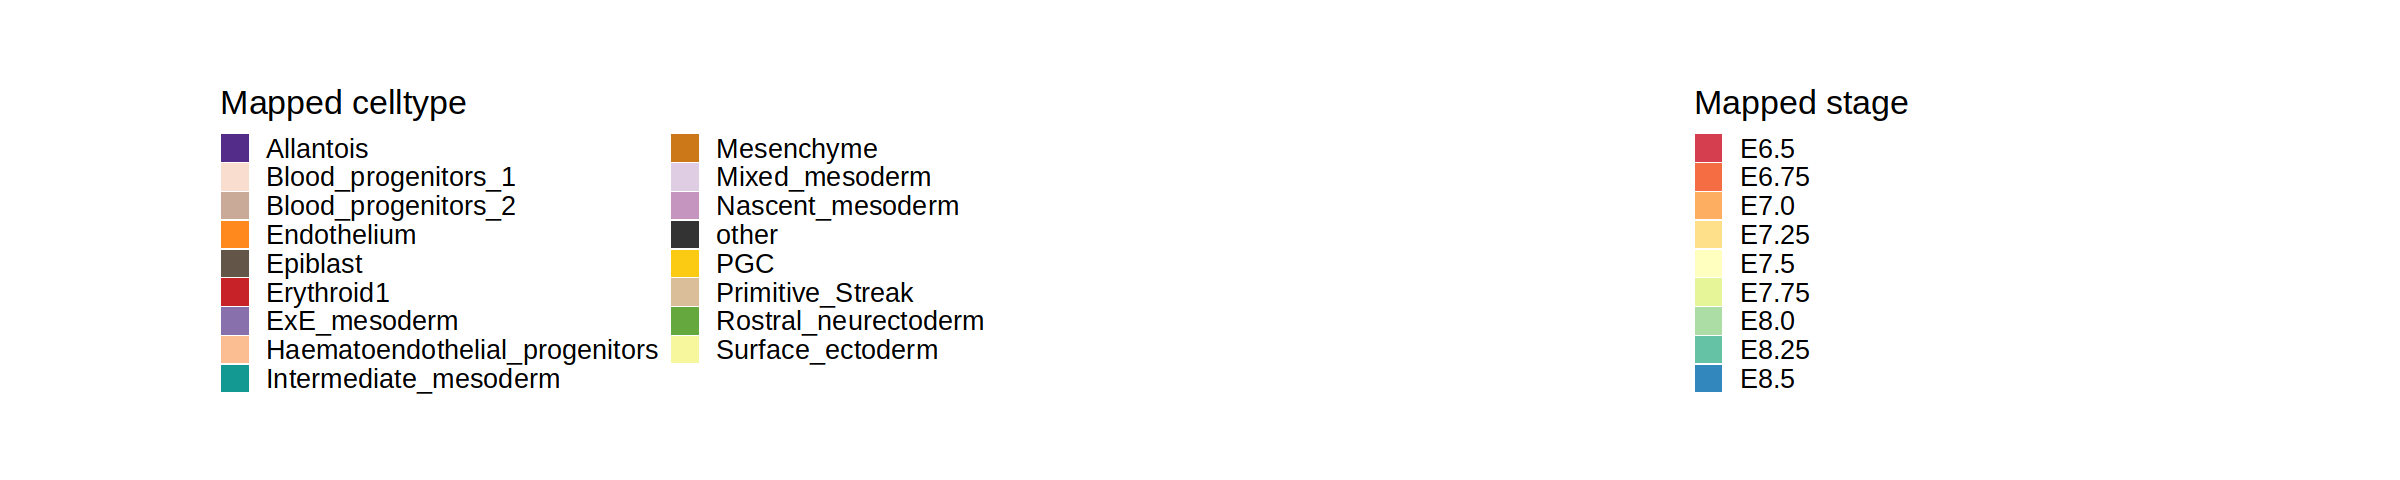

In [80]:
ggarrange(get_legend(p1 + theme(legend.position = 'right') +   guides(fill = guide_legend(ncol = 2))),
         get_legend(p3))